# Level 3

In [1]:
import pandas as pd

df = pd.read_csv("churn-bigml-20.csv")

print(df.shape)
df.head()

(667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    fl

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [3]:
print(df['Churn'].unique())

[False  True]


In [4]:
df['Churn'] = df['Churn'].map({True: 1, False: 0})

In [5]:
df = pd.get_dummies(df, drop_first=True)

In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [9]:
from sklearn.metrics import accuracy_score, classification_report

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

c:\Users\HR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Accuracy: 0.8955223880597015
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       119
           1       0.56      0.33      0.42        15

    accuracy                           0.90       134
   macro avg       0.74      0.65      0.68       134
weighted avg       0.88      0.90      0.88       134


Decision Tree
Accuracy: 0.9029850746268657
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       119
           1       0.55      0.73      0.63        15

    accuracy                           0.90       134
   macro avg       0.76      0.83      0.79       134
weighted avg       0.92      0.90      0.91       134


Random Forest
Accuracy: 0.9402985074626866
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       119
           1       1.00      0.47      0.64        15

    accuracy                           0.94 

In [10]:
best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", results[best_model])


Best Model: Random Forest
Best Accuracy: 0.9402985074626866


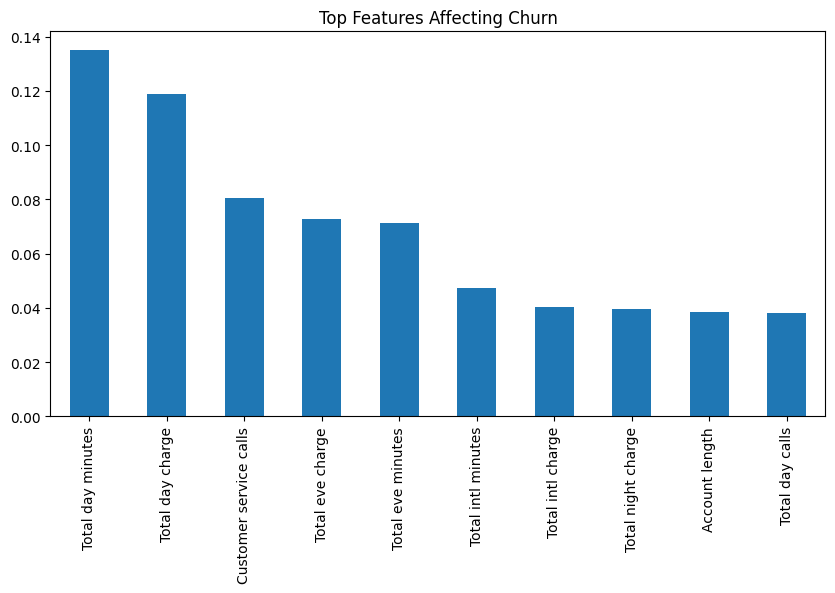

In [11]:
import matplotlib.pyplot as plt

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Features Affecting Churn")
plt.show()